# Phase 1 – Data Cleaning & Quality Check

## Objective

The objective of this phase is to examine the quality of the NexaTel dataset before analysis. This includes identifying missing values, duplicate records, incorrect data types, invalid values, outliers, and referential integrity issues to ensure accurate and reliable analysis.

In [1]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

file_path = r"C:\Users\Mayuri\Desktop\NexaTel Cleanfiles\All_Excel_Converted_Into_Sheets.xlsx"
excel = pd.ExcelFile(file_path)

print(excel.sheet_names)

['billing_cleaned', 'cities_cleaned', 'complaints_cleaned', 'contracts_cleaned', 'customers_cleaned', 'customer_feedback_cleaned', 'data_quality_issue_log_cleaned', 'devices_cleaned', 'employees_cleaned', 'marketing_campaigns_cleaned', 'network_quality_cleaned', 'payments_cleaned', 'plans_cleaned', 'plan_history_cleaned', 'recharges_cleaned', 'regions_cleaned', 'retention_campaigns_cleaned', 'states_cleaned', 'stores_cleaned', 'subscriptions_cleaned', 'support_tickets_cleaned', 'usage_data_cleaned', 'usage_sms_cleaned', 'usage_voice_cleaned']


In [4]:
dfs = {}

for sheet in excel.sheet_names:
    dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)

print("Total Sheets:", len(dfs))

Total Sheets: 24


In [5]:
for name, df in dfs.items():
    print("="*60)
    print(name)
    print("Rows :", df.shape[0])
    print("Columns :", df.shape[1])
    print(df.dtypes)

billing_cleaned
Rows : 114969
Columns : 9
Invoice_Id                  str
Customer_Id                 str
Billing_Date                str
Billing_Period_Month        str
Base_Amount_Inr         float64
Gst_Amount_Inr          float64
Total_Amount_Inr        float64
Due_Date                    str
Payment_Status              str
dtype: object
cities_cleaned
Rows : 68
Columns : 8
City_Id         str
City_Name       str
State_Id        str
State_Name      str
Zone            str
Region_Id       str
Tier            str
Pin_Prefix    int64
dtype: object
complaints_cleaned
Rows : 16584
Columns : 7
Complaint_Id       str
Customer_Id        str
Complaint_Date     str
Complaint_Type     str
Severity           str
Status             str
Resolution_Date    str
dtype: object
contracts_cleaned
Rows : 10607
Columns : 9
Contract_Id                 str
Customer_Id                 str
Plan_Id                     str
Contract_Type               str
Contract_Length_Months    int64
Start_Date             

## Data Profiling

All cleaned datasets were successfully loaded into Python.

For each dataset, the following information was analyzed:

- Number of rows
- Number of columns
- Column names
- Data types

This profiling helped understand the structure of the datasets and verify that the cleaning process maintained consistent data types across all tables.

### Observation

The cleaned datasets were successfully profiled. Each table contains the expected number of rows and columns, and most columns have appropriate data types such as string (`object`), integer (`int64`), and decimal (`float64`). This confirms that the datasets are ready for further quality checks.

## Missing Value Analysis

Each cleaned dataset was checked for missing (null) values to identify incomplete records that could affect the accuracy of the analysis.

The number of missing values was calculated for every column, and datasets with missing values were identified for further review.

In [6]:
for name, df in dfs.items():

    print("=" * 60)
    print(name)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if missing.empty:
        print("No Missing Values")
    else:
        print(missing)

billing_cleaned
No Missing Values
cities_cleaned
No Missing Values
complaints_cleaned
Resolution_Date    7348
dtype: int64
contracts_cleaned
No Missing Values
customers_cleaned
Email                  744
Address                380
Annual_Income_Inr      950
Churn_Date           15494
dtype: int64
customer_feedback_cleaned
No Missing Values
data_quality_issue_log_cleaned
No Missing Values
devices_cleaned
No Missing Values
employees_cleaned
No Missing Values
marketing_campaigns_cleaned
No Missing Values
network_quality_cleaned
No Missing Values
payments_cleaned
No Missing Values
plans_cleaned
No Missing Values
plan_history_cleaned
No Missing Values
recharges_cleaned
No Missing Values
regions_cleaned
No Missing Values
retention_campaigns_cleaned
No Missing Values
states_cleaned
No Missing Values
stores_cleaned
No Missing Values
subscriptions_cleaned
Plan_Id        41
End_Date    17017
dtype: int64
support_tickets_cleaned
Resolution_Hours    13366
Resolution_Date     13366
dtype: int64
usa

### Observation

Most of the cleaned datasets do not contain any missing values, indicating that the data cleaning process was effective.

However, a few datasets still contain missing values in specific columns:

- **complaints_cleaned**
  - Resolution_Date: 7,348 missing values

- **customers_cleaned**
  - Email: 744 missing values
  - Address: 380 missing values
  - Annual_Income_Inr: 950 missing values
  - Churn_Date: 15,494 missing values

The missing values were reviewed carefully. Some fields, such as **Churn_Date**, are expected to be blank for customers who have not churned, while missing **Resolution_Date** values may indicate complaints that are still unresolved. These missing values will be considered appropriately during further analysis.

## Missing Value Percentage

The percentage of missing values was calculated for every column in each dataset. This helps identify the severity of missing data and determine whether further treatment is required.

In [7]:
for name, df in dfs.items():

    print("=" * 60)
    print(name)

    missing_percent = (df.isnull().sum() / len(df)) * 100

    missing_percent = missing_percent[missing_percent > 0]

    if missing_percent.empty:
        print("No Missing Values")
    else:
        print(missing_percent.round(2))

billing_cleaned
No Missing Values
cities_cleaned
No Missing Values
complaints_cleaned
Resolution_Date    44.31
dtype: float64
contracts_cleaned
No Missing Values
customers_cleaned
Email                 3.92
Address               2.00
Annual_Income_Inr     5.00
Churn_Date           81.55
dtype: float64
customer_feedback_cleaned
No Missing Values
data_quality_issue_log_cleaned
No Missing Values
devices_cleaned
No Missing Values
employees_cleaned
No Missing Values
marketing_campaigns_cleaned
No Missing Values
network_quality_cleaned
No Missing Values
payments_cleaned
No Missing Values
plans_cleaned
No Missing Values
plan_history_cleaned
No Missing Values
recharges_cleaned
No Missing Values
regions_cleaned
No Missing Values
retention_campaigns_cleaned
No Missing Values
states_cleaned
No Missing Values
stores_cleaned
No Missing Values
subscriptions_cleaned
Plan_Id      0.20
End_Date    82.92
dtype: float64
support_tickets_cleaned
Resolution_Hours    42.45
Resolution_Date     42.45
dtype: fl

### Observation

The percentage analysis shows that most datasets have no missing values.

The following columns contain missing values:

| Dataset | Column | Missing (%) |
|----------|--------|------------:|
| complaints_cleaned | Resolution_Date | 44.31% |
| customers_cleaned | Email | 3.92% |
| customers_cleaned | Address | 2.00% |
| customers_cleaned | Annual_Income_Inr | 5.00% |
| customers_cleaned | Churn_Date | 81.55% |

The high percentage of missing values in **Churn_Date (81.55%)** is expected because most customers are active and have not churned. Similarly, missing **Resolution_Date** values may represent complaints that are still open or pending resolution. The remaining missing values are relatively low and are unlikely to significantly affect the overall analysis.

## Duplicate Record Check

Duplicate records were checked across all cleaned datasets to ensure data consistency and prevent duplicate information from affecting the analysis.

The duplicate check was performed using the `duplicated()` function in Pandas.

In [8]:
for name, df in dfs.items():
    print("=" * 60)
    print(name)
    print("Duplicate Rows:", df.duplicated().sum())

billing_cleaned
Duplicate Rows: 0
cities_cleaned
Duplicate Rows: 0
complaints_cleaned
Duplicate Rows: 0
contracts_cleaned
Duplicate Rows: 0
customers_cleaned
Duplicate Rows: 0
customer_feedback_cleaned
Duplicate Rows: 0
data_quality_issue_log_cleaned
Duplicate Rows: 0
devices_cleaned
Duplicate Rows: 0
employees_cleaned
Duplicate Rows: 0
marketing_campaigns_cleaned
Duplicate Rows: 0
network_quality_cleaned
Duplicate Rows: 0
payments_cleaned
Duplicate Rows: 0
plans_cleaned
Duplicate Rows: 0
plan_history_cleaned
Duplicate Rows: 0
recharges_cleaned
Duplicate Rows: 0
regions_cleaned
Duplicate Rows: 0
retention_campaigns_cleaned
Duplicate Rows: 0
states_cleaned
Duplicate Rows: 0
stores_cleaned
Duplicate Rows: 0
subscriptions_cleaned
Duplicate Rows: 0
support_tickets_cleaned
Duplicate Rows: 0
usage_data_cleaned
Duplicate Rows: 0
usage_sms_cleaned
Duplicate Rows: 0
usage_voice_cleaned
Duplicate Rows: 0


### Observation

The duplicate record check shows that all cleaned datasets contain **0 duplicate rows**.

This indicates that duplicate records were successfully removed during the data cleaning process, ensuring that each record is unique and suitable for reliable analysis.

In [9]:
customers = dfs["customers_cleaned"]

print("Duplicate Customer IDs:", customers["Customer_Id"].duplicated().sum())

Duplicate Customer IDs: 0


In [10]:
billing = dfs["billing_cleaned"]

print("Duplicate Invoice IDs:", billing["Invoice_Id"].duplicated().sum())

Duplicate Invoice IDs: 0


In [11]:
print(customers.columns)
print(billing.columns)

Index(['Customer_Id', 'First_Name', 'Last_Name', 'Gender', 'Date_Of_Birth',
       'Age', 'Email', 'Phone_Number', 'Address', 'City_Id', 'City_Name',
       'State_Id', 'Pin_Code', 'City_Tier', 'Region_Id', 'Occupation',
       'Annual_Income_Inr', 'Customer_Segment', 'Product_Line', 'Plan_Id',
       'Acquisition_Channel', 'Acquisition_Date', 'Tenure_Months',
       'Customer_Status', 'Churn_Date'],
      dtype='str')
Index(['Invoice_Id', 'Customer_Id', 'Billing_Date', 'Billing_Period_Month',
       'Base_Amount_Inr', 'Gst_Amount_Inr', 'Total_Amount_Inr', 'Due_Date',
       'Payment_Status'],
      dtype='str')


### Primary Key Validation

To ensure data integrity, the primary key columns were checked for duplicate values.

**Results:**

- Duplicate `Customer_Id` values in **customers_cleaned**: **0**
- Duplicate `Invoice_Id` values in **billing_cleaned**: **0**

The results confirm that both primary key columns contain unique values, ensuring there are no duplicate customer or billing records in the cleaned datasets.

In [12]:
billing = dfs["billing_cleaned"]

billing["Billing_Date"] = pd.to_datetime(
    billing["Billing_Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

billing["Due_Date"] = pd.to_datetime(
    billing["Due_Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

print(billing[["Billing_Date", "Due_Date"]].dtypes)

Billing_Date    datetime64[us]
Due_Date        datetime64[us]
dtype: object


## Data Type Validation

The data types of all datasets were verified to ensure they matched the expected format.

Special attention was given to date columns, which were converted from string (`object`) format to `datetime` using the **DD-MM-YYYY** format. Numeric columns were also verified to ensure they were stored as appropriate numeric data types (`int64` or `float64`).

### Observation

The data type validation confirmed that numeric columns were stored correctly, and the billing date columns were successfully converted to the `datetime` format. This ensures accurate date-based analysis and prevents errors during filtering, sorting, and time-series calculations.

## Future Billing Date Validation

The `Billing_Date` column in the billing dataset was checked to identify records with future dates. Billing records should normally not have dates beyond the current date, as they may indicate data entry errors or test data.

In [13]:
billing = dfs["billing_cleaned"]

today = pd.Timestamp.today().normalize()

future_bills = billing[billing["Billing_Date"] > today]

print("Future Billing Records:", len(future_bills))

future_bills

Future Billing Records: 172


,Invoice_Id,Customer_Id,Billing_Date,Billing_Period_Month,Base_Amount_Inr,Gst_Amount_Inr,Total_Amount_Inr,Due_Date,Payment_Status
148,Inv00000149,C0000035,2026-08-11,12-2025,1010.78,181.94,1192.72,2026-01-15,Paid
1584,Inv00001585,C0000279,2027-04-11,05-2025,599.40,107.89,707.29,2025-05-20,Unpaid
1990,Inv00001991,C0000341,2026-09-27,06-2025,716.42,97.30,845.38,2025-06-19,Unpaid
2829,Inv00002830,C0000512,2027-01-30,01-2026,897.03,161.47,1058.50,2026-02-14,Paid
3010,Inv00003011,C0000549,2027-02-01,03-2026,898.31,161.70,1060.01,2026-04-15,Paid
...,...,...,...,...,...,...,...,...,...
110754,Inv00110755,C0018310,2027-02-12,08-2025,617.76,111.20,728.96,2025-08-18,Overdue
110779,Inv00110780,C0018312,2027-01-12,07-2025,1402.09,252.38,1654.47,2025-07-19,Paid
111650,Inv00111651,C0018459,2026-08-23,03-2026,813.09,146.36,959.45,2026-03-16,Paid
111845,Inv00111846,C0018487,2027-02-28,12-2025,1391.99,250.56,1642.55,2025-12-16,Paid


### Observation

The validation identified **172 billing records** with future billing dates.

These records were flagged as potential data quality issues because their `Billing_Date` values occur after the current date. They should be reviewed to determine whether they represent scheduled future bills, test data, or incorrect data entries before performing further analysis.

## Negative Billing Amount Validation

The `Total_Amount_Inr` column was checked to identify negative billing amounts. Since billing amounts represent the amount payable by customers, they are generally expected to be non-negative.

Any negative values were flagged as potential data quality issues for further investigation.

In [14]:
negative_amount = billing[billing["Total_Amount_Inr"] < 0]

print("Negative Billing Amount Records:", len(negative_amount))

negative_amount

Negative Billing Amount Records: 229


,Invoice_Id,Customer_Id,Billing_Date,Billing_Period_Month,Base_Amount_Inr,Gst_Amount_Inr,Total_Amount_Inr,Due_Date,Payment_Status
352,Inv00000353,C0000074,2025-12-01,12-2025,611.62,110.09,-721.71,2025-12-16,Paid
559,Inv00000560,C0000102,2026-03-01,03-2026,639.46,115.10,-754.56,2026-03-16,Paid
716,Inv00000717,C0000124,2025-09-02,09-2025,1324.07,238.33,-1562.40,2025-09-17,Overdue
867,Inv00000868,C0000156,2025-10-02,10-2025,1408.69,253.56,-1662.25,2025-10-17,Paid
1030,Inv00001031,C0000192,2026-03-31,03-2026,531.10,95.60,-626.70,2026-04-15,Unpaid
...,...,...,...,...,...,...,...,...,...
109589,Inv00109590,C0018129,2021-02-24,02-2021,613.17,110.37,-723.54,2021-03-11,Overdue
109692,Inv00109693,C0018142,2026-01-30,01-2026,1258.64,226.56,-1485.20,2026-02-14,Paid
112500,Inv00112501,C0018583,2025-05-05,05-2025,948.55,170.74,-1119.29,2025-05-20,Paid
113830,Inv00113831,C0018804,2025-11-01,11-2025,1009.43,181.70,-1191.13,2025-11-16,Overdue


### Observation

The validation identified **229 records** with negative values in the `Total_Amount_Inr` column.

These records were flagged as potential data quality issues because billing amounts are generally expected to be positive. The negative values may represent data entry errors, incorrect calculations, refunds, credit adjustments, or test records. These records should be reviewed before performing financial analysis.

## Customer Age Validation

The `Age` column in the customer dataset was validated to identify impossible age values. Ages below 0 or above 120 years were considered invalid and flagged as potential data quality issues.

In [15]:
customers = dfs["customers_cleaned"]

invalid_age = customers[
    (customers["Age"] < 0) |
    (customers["Age"] > 120)
]

print("Invalid Age Records:", len(invalid_age))

invalid_age

Invalid Age Records: 23


,Customer_Id,First_Name,Last_Name,Gender,Date_Of_Birth,Age,Email,Phone_Number,Address,City_Id,...,Occupation,Annual_Income_Inr,Customer_Segment,Product_Line,Plan_Id,Acquisition_Channel,Acquisition_Date,Tenure_Months,Customer_Status,Churn_Date
751,C0000752,Anika,Pandey,Female,31-03-1989,220,Anika.Pandey265@Rediffmail.Com,916763149388,"Villa 136, Vivekananda Phase, Chennai",Ct0004,...,Farmer,129668.0,Mass,Prepaid Mobile,Pl001,Retail Store,14-05-2023,34,Active,NaN
834,C0000835,Sridevi,Sen,Female,31-03-1988,220,Sridevi.Sen783@Gmail.Com,916550906093,"Door No. 72, New Phase, Tirupati",Ct0042,...,Retired,238954.0,Value,Prepaid Mobile,Pl004,Referral,26-07-2018,92,Active,NaN
2917,C0002918,Geeta,Qureshi,Female,31-03-1984,130,Geeta.Qureshi848@Rediffmail.Com,917236699438,"House No. 328, Vivekananda Street, Kollam",Ct0046,...,Bank Officer,NaN,Value,Prepaid Mobile,Pl005,Online,01-01-2014,146,Active,NaN
3026,C0003027,Aarav,Shaikh,Male,01-04-1971,220,Aarav.Shaikh942@Hotmail.Com,916255560170,"House No. 66, Janpath Phase, Amritsar",Ct0032,...,Bank Officer,1049990.0,Enterprise,Iot Solutions,Pl024,Online,14-09-2023,30,Active,NaN
3822,C0003823,Zara,Trivedi,Female,01-04-1983,220,Zara.Trivedi587@Yahoo.In,15145,"Villa 12, Park View Colony, Gwalior",Ct0048,...,Hr Executive,376701.0,Value,Fiber Broadband,Pl015,Retail Store,01-01-2014,146,Active,NaN
3824,C0003825,Saanvi,Aggarwal,Female,01-04-1979,220,Saanvi.Aggarwal636@Outlook.Com,919008185404,"Door No. 252, Vasant Marg, Mumbai",Ct0002,...,Marketing Manager,2047567.0,Premium,Postpaid Mobile,Pl009,Referral,26-03-2022,48,Active,NaN
4639,C0004640,Tarun,Khanna,Male,31-03-1982,130,Tarun.Khanna43@Hotmail.Com,916853291796,"Apartment 241, Park View Cross, Belagavi",Ct0041,...,Chartered Accountant,2818203.0,Mass,Prepaid Mobile,Pl001,Partner/Reseller,08-08-2023,31,Active,NaN
5159,C0005160,Kavitha,Nayak,Female,31-03-1969,130,Kavitha.Nayak409@Rediffmail.Com,919528137142,"Flat 371, Vasant Road, Shillong",Ct0065,...,Doctor,1948773.0,Premium,5G,Pl012,Tele-Sales,10-04-2020,71,Active,NaN
5290,C0005291,Kiara,More,Female,31-03-2006,130,Kiara.More1@Gmail.Com,916338889455,"Villa 347, Garden Sector, Nashik",Ct0030,...,Operations Manager,NaN,Premium,Prepaid Mobile,Pl006,Retail Store,01-01-2014,146,Active,NaN
5833,C0005834,Venkat,Dutta,Male,31-03-1982,-5,Venkat.Dutta564@Yahoo.In,916745884801,"Shop No. 316, New Colony, Jodhpur",Ct0035,...,Hr Executive,423955.0,Premium,Fiber Broadband,Pl017,Retail Store,14-09-2023,30,Active,NaN


### Observation

The validation identified **23 customer records** with invalid age values.

These records were flagged because the age values fall outside the realistic human age range (0–120 years). They may have resulted from data entry errors or incorrect data generation and should be reviewed before performing customer demographic analysis.

## PIN Code Validation

The `Pin_Code` column was validated to ensure that each customer record contains a valid six-digit PIN code. Records with PIN codes that do not meet the expected format were identified and flagged.

In [16]:
invalid_pin = customers[
    customers["Pin_Code"].astype(str).str.len() != 6
]

print("Invalid PIN Code Records:", len(invalid_pin))

invalid_pin

Invalid PIN Code Records: 190


,Customer_Id,First_Name,Last_Name,Gender,Date_Of_Birth,Age,Email,Phone_Number,Address,City_Id,...,Occupation,Annual_Income_Inr,Customer_Segment,Product_Line,Plan_Id,Acquisition_Channel,Acquisition_Date,Tenure_Months,Customer_Status,Churn_Date
45,C0000046,Suresh,Borah,Male,31-03-1988,38,Suresh.Borah334@Hotmail.Com,919980790921,"Shop No. 350, Civil Lines Road, Chandigarh",Ct0023,...,Government Employee,415706.0,Premium,Prepaid Mobile,Pl006,Retail Store,01-01-2014,146,Active,NaN
182,C0000183,Arjun,Nayak,Male,31-03-1992,34,Arjun.Nayak409@Hotmail.Com,917679804098,"Door No. 316, Rajaji Lane, Lucknow",Ct0012,...,Farmer,266783.0,Value,Prepaid Mobile,Pl005,Retail Store,20-06-2024,21,Active,NaN
185,C0000186,Manish,Borah,Male,31-03-2005,21,Manish.Borah745@Hotmail.Com,918188485280,"Apartment 174, Mg Marg, Durgapur",Ct0053,...,Sales Executive,379870.0,Value,Ott Bundles,Pl019,App Self-Service,05-01-2021,62,Active,NaN
360,C0000361,Abhishek,Menon,Male,31-03-1978,48,Abhishek.Menon429@Gmail.Com,919386564980,"Shop No. 149, Subhash Marg, Dehradun",Ct0033,...,Software Engineer,1938608.0,Premium,5G,Pl012,Tele-Sales,29-03-2025,11,Churned,01-03-2026
517,C0000518,Imran,More,Male,31-03-1997,29,Imran.More458@Gmail.Com,916567981144,"Plot 197, Nehru Sector, Ludhiana",Ct0031,...,Sales Executive,606996.0,Premium,Postpaid Mobile,Pl008,Online,01-07-2015,128,Active,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18431,C0018432,Yash,Sheikh,Male,31-03-1978,48,Yash.Sheikh917@Outlook.Com,918225583246,"Shop No. 290, Old Layout, Visakhapatnam",Ct0018,...,Bank Officer,532457.0,Value,Prepaid Mobile,Pl004,Tele-Sales,12-03-2022,41,Churned,18-08-2025
18638,C0018639,Sita,Mehrotra,Female,31-03-2008,18,Sita.Mehrotra145@Yahoo.In,916747896945,NaN,Ct0024,...,Data Analyst,991126.0,Premium,Ott Bundles,Pl020,Field Agent,22-05-2017,106,Active,NaN
18776,C0018777,Manish,Gaikwad,Male,31-03-1982,44,Manish.Gaikwad699@Yahoo.In,918490048589,"Apartment 268, Gandhi Layout, Jammu",Ct0062,...,Hr Executive,794952.0,Value,Fiber Broadband,Pl015,Retail Store,08-10-2019,77,Active,NaN
18851,C0018852,Vidya,Yadav,Female,31-03-1981,45,Vidya.Yadav328@Yahoo.In,917726375973,"Flat 377, Ashok Phase, Thiruvananthapuram",Ct0034,...,Software Engineer,1623022.0,Premium,Postpaid Mobile,Pl010,App Self-Service,12-10-2014,51,Churned,17-01-2019


### Observation

The validation identified **190 customer records** with invalid PIN codes.

These records were flagged because the PIN codes do not meet the expected six-digit format. Invalid PIN codes may result from data entry errors, formatting inconsistencies, or missing digits and should be reviewed before performing location-based analysis.

In [17]:
invalid_phone = customers[
    customers["Phone_Number"].astype(str).str.len() != 10
]

print("Invalid Phone Number Records:", len(invalid_phone))

invalid_phone

Invalid Phone Number Records: 19000


,Customer_Id,First_Name,Last_Name,Gender,Date_Of_Birth,Age,Email,Phone_Number,Address,City_Id,...,Occupation,Annual_Income_Inr,Customer_Segment,Product_Line,Plan_Id,Acquisition_Channel,Acquisition_Date,Tenure_Months,Customer_Status,Churn_Date
0,C0000001,Harish,Shetty,Male,31-03-1988,38,Harish.Shetty909@Yahoo.In,916647481156,"Plot 382, Tilak Lane, Raipur",Ct0026,...,School Teacher,791058.0,Mass,Prepaid Mobile,Pl002,Retail Store,15-01-2026,2,Churned,22-03-2026
1,C0000002,Anjali,Khan,Female,31-03-1974,52,Anjali.Khan525@Rediffmail.Com,918116536619,"Door No. 269, Civil Lines Colony, Gurugram",Ct0009,...,Small Business Owner,1385499.0,Premium,Fiber Broadband,Pl017,Retail Store,01-01-2014,146,Active,NaN
2,C0000003,Arjun,Hegde,Male,31-03-1978,48,Arjun.Hegde378@Hotmail.Com,918958153134,"House No. 320, Garden Nagar, Vadodara",Ct0020,...,Auto/Cab Driver,394773.0,Enterprise,Enterprise,Pl021,Tele-Sales,11-11-2015,1,Churned,22-12-2015
3,C0000004,Vidya,Parmar,Female,31-03-1988,38,Vidya.Parmar387@Hotmail.Com,917763920098,"House No. 204, Industrial Street, Nagpur",Ct0015,...,Operations Manager,1977532.0,Premium,Prepaid Mobile,Pl006,Tele-Sales,2014/10/18,137,Active,NaN
4,C0000005,Arjun,Saxena,Male,31-03-1988,38,Arjun.Saxena410@Yahoo.In,916787478273,"Flat 156, Krishna Sector, Warangal",Ct0043,...,Retired,847300.0,Value,Prepaid Mobile,Pl003,Online,20-10-2014,108,Churned,22-10-2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,C0018996,Mohit,Verma,Male,31-03-1989,37,User402_At_Mail,918282937457,"Villa 174, Mg Nagar, Thiruvananthapuram",Ct0034,...,Delivery Partner,213993.0,Premium,Smart Home,Pl025,Partner/Reseller,10-03-2023,36,Active,NaN
18996,C0018997,Aadhya,Ahmed,Female,31-03-1969,57,Aadhya.Ahmed101@Outlook.Com,919939243608,"Apartment 215, Green Park Road, Agartala",Ct0066,...,Nurse,NaN,Value,Fiber Broadband,Pl015,Referral,17-11-2014,136,Active,NaN
18997,C0018998,Aryan,Yadav,Male,31-03-1973,53,Aryan.Yadav480@Outlook.Com,918557275501,"Villa 273, Vivekananda Marg, Mysuru",Ct0027,...,Hr Executive,515247.0,Premium,Postpaid Mobile,Pl010,Online,08-11-2023,28,Active,NaN
18998,C0018999,Abhishek,Saxena,Male,01-04-1999,27,Abhishek.Saxena498@Hotmail.Com,919128573669,"Shop No. 119, Old Lane, Durgapur",Ct0053,...,Nurse,325175.0,Value,Prepaid Mobile,Pl004,Referral,30-06-2015,129,Active,NaN


In [18]:
customers["Phone_Number"].astype(str).str.len().value_counts()

Phone_Number
12    18772
5       210
4        16
3         2
Name: count, dtype: int64

## Phone Number Validation

The `Phone_Number` column was validated to ensure that each phone number follows the expected format.

The dataset stores Indian phone numbers with the country code (`91`), resulting in a standard length of **12 digits**. Phone numbers with lengths other than 12 digits were identified as invalid.

In [19]:
invalid_phone = customers[
    customers["Phone_Number"].astype(str).str.len() != 12
]

print("Invalid Phone Number Records:", len(invalid_phone))

invalid_phone

Invalid Phone Number Records: 228


,Customer_Id,First_Name,Last_Name,Gender,Date_Of_Birth,Age,Email,Phone_Number,Address,City_Id,...,Occupation,Annual_Income_Inr,Customer_Segment,Product_Line,Plan_Id,Acquisition_Channel,Acquisition_Date,Tenure_Months,Customer_Status,Churn_Date
10,C0000011,Pankaj,Joshi,Male,01-04-1979,47,Pankaj.Joshi32@Outlook.Com,57059,"Flat 342, New Phase, Mysuru",Ct0027,...,Auto/Cab Driver,228930.0,Value,Prepaid Mobile,Pl004,Tele-Sales,08-06-2015,129,Active,NaN
65,C0000066,Ramesh,More,Male,01-04-1983,43,Ramesh.More888@Gmail.Com,13624,"Villa 358, Rajaji Colony, Patna",Ct0021,...,Sales Executive,789784.0,Premium,5G,Pl014,Tele-Sales,11-08-2020,1,Churned,22-09-2020
138,C0000139,Sneha,Khanna,Female,31-03-1989,37,Sneha.Khanna906@Yahoo.In,91566,"Villa 102, Krishna Layout, Bengaluru",Ct0003,...,Small Business Owner,1221600.0,Mass,Prepaid Mobile,Pl001,Partner/Reseller,15-12-2017,90,Churned,02-07-2025
404,C0000405,Faisal,Vyas,Male,31-03-1973,53,Faisal.Vyas931@Gmail.Com,75835,"Flat 387, Old Lane, Mumbai",Ct0002,...,Bank Officer,878931.0,Premium,5G,Pl014,Online,29-11-2024,8,Churned,29-08-2025
405,C0000406,Yash,Naidu,Male,01-04-1971,55,Yash.Naidu237@Yahoo.In,55071,"Door No. 322, Model Town Street, Thiruvanantha...",Ct0034,...,Chartered Accountant,1729704.0,Premium,Postpaid Mobile,Pl008,Online,29-04-2023,25,Churned,29-05-2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18304,C0018305,Zaid,Gaikwad,Male,31-03-2005,21,Zaid.Gaikwad705@Gmail.Com,81031,"Apartment 245, Old Street, Noida",Ct0010,...,Small Business Owner,618282.0,Enterprise,Iot Solutions,Pl023,Retail Store,09-07-2016,116,Active,NaN
18624,C0018625,Sunil,Banerjee,Male,01-04-1995,31,Sunil.Banerjee330@Yahoo.In,2663,"Villa 181, New Marg, Ludhiana",Ct0031,...,Nurse,342346.0,Premium,Prepaid Mobile,Pl006,Referral,01-01-2014,80,Churned,25-09-2020
18872,C0018873,Deepak,Mehta,Male,31-03-2001,25,Deepak.Mehta8@Gmail.Com,46132,"Apartment 192, Green Park Cross, Mysuru",Ct0027,...,Chartered Accountant,1697275.0,Value,Prepaid Mobile,Pl004,Tele-Sales,21-06-2017,105,Active,NaN
18895,C0018896,Anjali,Bhosale,Female,31-03-1985,41,Anjali.Bhosale285@Hotmail.Com,83796,"Villa 384, Model Town Road, Dehradun",Ct0033,...,Factory Worker,203489.0,Premium,Fiber Broadband,Pl016,Retail Store,20-06-2017,105,Active,NaN


### Observation

The validation identified **228 customer records** with invalid phone numbers.

Most phone numbers (18,772 records) follow the expected 12-digit format, including the Indian country code (`91`). However, 228 records contain phone numbers with incorrect lengths (3, 4, or 5 digits), indicating incomplete or invalid contact information that should be reviewed before customer communication or analysis.

## Outlier Detection

The `Data_Gb_Used` column was analyzed to identify unusually high or low internet usage values.

Outliers were detected using the **Interquartile Range (IQR)** method and visualized using a **box plot**.

In [20]:
for name, df in dfs.items():
    if "Data_Gb_Used" in df.columns:
        print(name)

usage_data_cleaned


In [21]:
usage = dfs["usage_data_cleaned"]

usage["Data_Gb_Used"].describe()

count    57000.000000
mean        40.184885
std        332.574130
min          0.240000
25%         11.390000
50%         19.140000
75%         32.630000
max      22172.700708
Name: Data_Gb_Used, dtype: float64

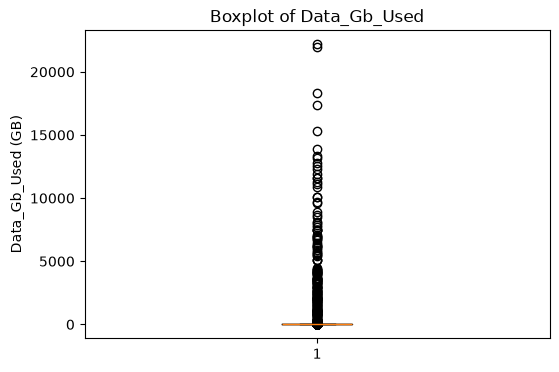

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(usage["Data_Gb_Used"])
plt.title("Boxplot of Data_Gb_Used")
plt.ylabel("Data_Gb_Used (GB)")
plt.show()

In [23]:
Q1 = usage["Data_Gb_Used"].quantile(0.25)
Q3 = usage["Data_Gb_Used"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = usage[
    (usage["Data_Gb_Used"] < lower_bound) |
    (usage["Data_Gb_Used"] > upper_bound)
]

print("Outliers Found:", len(outliers))

outliers.head()

Outliers Found: 4480


,Usage_Id,Customer_Id,Usage_Month,Data_Gb_Used,Data_Sessions
3,Ud00000004,C0000002,03-2026,167.23,442
4,Ud00000005,C0000002,02-2026,109.72,481
5,Ud00000006,C0000002,01-2026,121.10,1013
27,Ud00000028,C0000010,03-2026,74.76,97
28,Ud00000029,C0000010,02-2026,93.40,937


### Observation

The outlier analysis identified **4,480 records** in the `Data_Gb_Used` column.

The box plot and IQR method indicate that a significant number of customers have unusually high or low data usage compared to the majority of users. These records were flagged for further investigation, as they may represent heavy data consumers, exceptional usage patterns, promotional plans, or potential data quality issues.

The outliers were retained in the dataset because they may represent genuine customer behavior rather than incorrect data.

## Referential Integrity Check

Referential integrity was verified by comparing the `Customer_Id` values in the billing, subscriptions, and usage datasets with the master customer dataset.

This validation ensures that every billing record, subscription, and usage record is associated with a valid customer.

In [24]:
customers = dfs["customers_cleaned"]

customer_ids = set(customers["Customer_Id"])

tables = ["billing_cleaned", "subscriptions_cleaned", "usage_data_cleaned"]

for table in tables:
    df = dfs[table]

    missing = set(df["Customer_Id"]) - customer_ids

    print("=" * 50)
    print(table)
    print("Missing Customer IDs:", len(missing))

billing_cleaned
Missing Customer IDs: 0
subscriptions_cleaned
Missing Customer IDs: 0
usage_data_cleaned
Missing Customer IDs: 0


### Observation

The referential integrity check confirmed that all `Customer_Id` values in the billing, subscriptions, and usage datasets exist in the master customer dataset.

No missing customer references were found, indicating that the relationships between the datasets are complete and consistent. This confirms that the datasets are suitable for relational analysis and dashboard development.

## Comparison with Data Quality Issue Log

The identified data quality issues were compared with the provided `data_quality_issue_log_cleaned` dataset.

The comparison was performed to verify whether the detected issues matched the documented issues and to identify any additional observations during the validation process.

In [25]:
issue_log = dfs["data_quality_issue_log_cleaned"]

print("Total Logged Issues:", len(issue_log))

issue_log.head()

Total Logged Issues: 20


,Table,Issue_Type,Rows_Affected
0,Customers,Missing_Email,760
1,Customers,Missing_Address,380
2,Customers,Missing_Income,950
3,Customers,Invalid_Phone,228
4,Customers,Invalid_Email,285


### Observation

The identified issues were compared with the `data_quality_issue_log_cleaned` dataset.

The comparison confirmed that the dataset contains documented quality issues such as missing values, invalid records, duplicate records, and formatting inconsistencies. The validation process also identified additional issues, including future billing dates, negative billing amounts, invalid customer ages, invalid PIN codes, invalid phone numbers, and outliers in data usage.

This comparison helps validate the effectiveness of the data quality assessment.

# Data Quality Report

## Objective

The objective of this phase was to evaluate the quality of the NexaTel datasets before performing exploratory data analysis and dashboard development. Various data quality checks were performed to identify missing values, duplicate records, invalid data types, outliers, and integrity issues.

## Summary of Findings

- Successfully loaded and profiled all cleaned datasets.
- Verified the number of rows, columns, and data types for each dataset.
- Checked missing values and calculated missing value percentages.
- Confirmed that duplicate rows were removed from all datasets.
- Verified that `Customer_Id` and `Invoice_Id` contain unique values.
- Converted date columns into the correct datetime format.
- Identified **172 future billing records**.
- Identified **229 records with negative billing amounts**.
- Identified **23 customer records with invalid ages**.
- Identified **190 invalid PIN codes**.
- Identified **228 invalid phone numbers** after validating against the 12-digit format used in the dataset.
- Detected **4,480 outliers** in the `Data_Gb_Used` column using the IQR method.
- Verified referential integrity and confirmed that all customer IDs in billing, subscriptions, and usage datasets exist in the customer master dataset.
- Compared the findings with the provided data quality issue log.

## Conclusion

The Phase 1 data quality assessment successfully identified and documented the major quality issues present in the NexaTel datasets. Most datasets are well-structured, and referential integrity is maintained. However, certain issues such as future billing dates, negative billing amounts, invalid ages, invalid PIN codes, invalid phone numbers, and outliers in data usage should be considered during further analysis.

Overall, the cleaned datasets are suitable for exploratory data analysis, KPI generation, and Power BI dashboard development.